In [72]:
# General purpose
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Signal processing
from scipy.io import loadmat 
from scipy.ndimage import convolve1d
from scipy.signal import butter
from scipy.signal import sosfiltfilt
from scipy.signal import welch

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
# Hyperparameter tuning
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
# Feature selection
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest
# Dimensionality reduction
from sklearn.decomposition import PCA

RANDOM_STATE = 1
np.random.seed(RANDOM_STATE)

sns.set()


In [73]:
data = loadmat("data/S1_E1_A1.mat")
print("Dataset variables:")
print([key for key in data.keys() if not key.startswith("__")])

emg = data["emg"]
glove = data["glove"]
print("EMG data dimension (all channels): {}".format(emg.shape))
print("EMG data type: {}".format(type(emg)))
print("Glove data dimension (raw): {}".format(glove.shape))

stimulus = data["stimulus"]
repetition = data["repetition"]

N_STIMULI = len(np.unique(stimulus)) - 1  # -1 because 0 is the resting condition
N_REPETITIONS = len(np.unique(repetition)) - 1  # -1 because 0 is not a repetition

n_samples, n_emg_channels_all = emg.shape

# time alignment
assert emg.shape[0] == glove.shape[0] == stimulus.shape[0] == repetition.shape[0]

# --- Targets: select glove joint angles 3, 6, 8, 11, 14 (1-based in the hand picture) ---
glove_2d = glove
if glove_2d.ndim == 1:
    glove_2d = glove_2d.reshape(-1, 1)
elif glove_2d.ndim > 2:
    glove_2d = glove_2d.reshape(glove_2d.shape[0], -1)

joint_angles_1based = [3, 6, 8, 11, 14]
joint_idx = [j - 1 for j in joint_angles_1based]  # convert to 0-based indices
assert max(joint_idx) < glove_2d.shape[1], "Selected glove indices exceed available glove dimensions."
glove_sel = glove_2d[:, joint_idx]
joint_names = [f"angle{j}" for j in joint_angles_1based]
print("Selected glove targets:", list(zip(joint_names, joint_idx)))
print("Selected glove target dimension:", glove_sel.shape)

# --- Inputs: select EMG channels corresponding to thumb/index/middle/ring/pinky ---
# Thumb, Index, Middle, Ring, Pinky (0-based indices)
finger_channel_indices = [3, 6, 8, 11, 14]
finger_names = ["thumb", "index", "middle", "ring", "pinky"]
assert len(finger_channel_indices) == len(finger_names)
assert max(finger_channel_indices) < emg.shape[1], "Selected EMG channel index exceeds available channels."

emg = emg[:, finger_channel_indices]
channel_labels = finger_names
print("Selected EMG channels:", list(zip(finger_names, finger_channel_indices)))
print("EMG data dimension (selected channels): {}".format(emg.shape))

n_samples, n_channels = emg.shape

Dataset variables:
['subject', 'exercise', 'emg', 'acc', 'gyro', 'mag', 'glove', 'stimulus', 'repetition', 'restimulus', 'rerepetition']
EMG data dimension (all channels): (2292526, 16)
EMG data type: <class 'numpy.ndarray'>
Glove data dimension (raw): (2292526, 18)
Selected glove targets: [('angle3', 2), ('angle6', 5), ('angle8', 7), ('angle11', 10), ('angle14', 13)]
Selected glove target dimension: (2292526, 5)
Selected EMG channels: [('thumb', 3), ('index', 6), ('middle', 8), ('ring', 11), ('pinky', 14)]
EMG data dimension (selected channels): (2292526, 5)


### Separate fingers (before feature calculation)
We keep only EMG channels **3 (thumb), 6 (index), 8 (middle), 11 (ring), 14 (pinky)** and discard all other channels. All subsequent steps (feature extraction, correlation matrix, regression) operate on these five channels only.

In [74]:
fs = 2000 
t = np.arange(n_samples) / fs
print(f"Approx recording duration: {t[-1]:.1f} s")

Approx recording duration: 1146.3 s


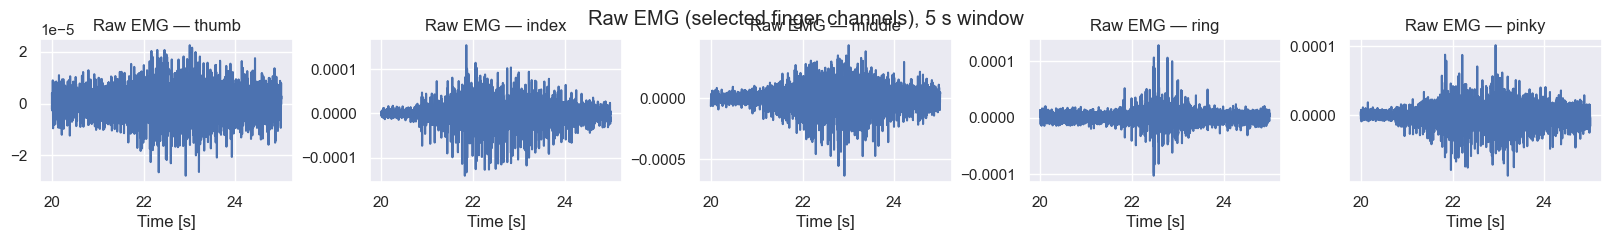

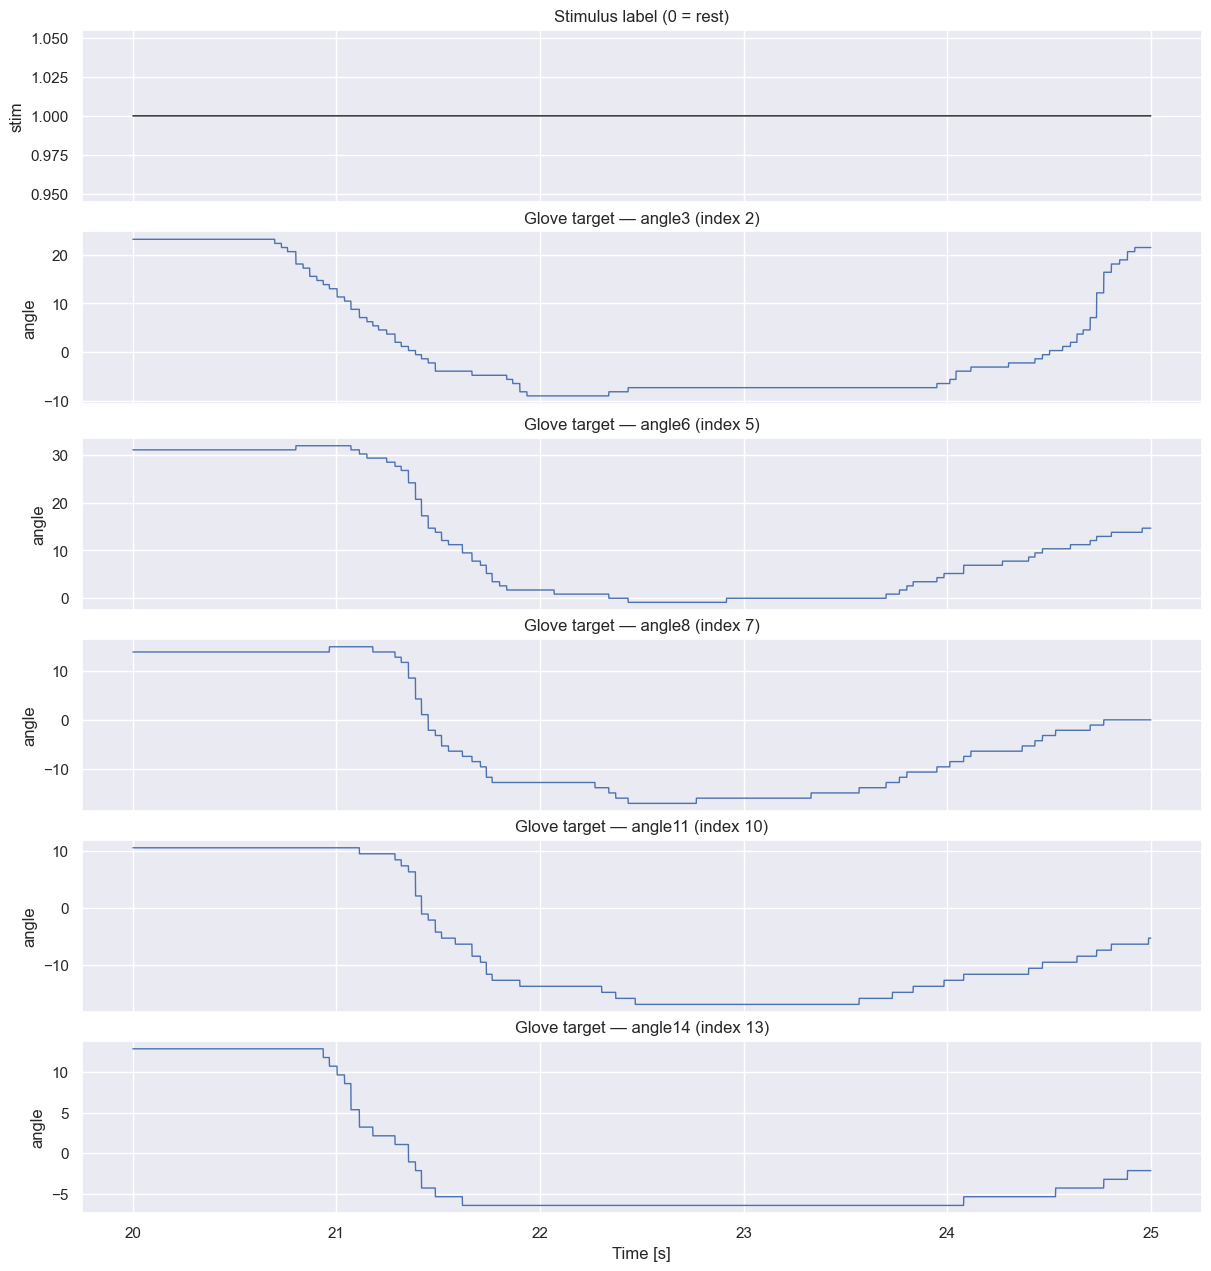

In [75]:
# pick a 5 s window somewhere in the middle
window_duration = 5  # seconds
start_time = 20      # seconds (you can change this)
start_idx = int(start_time * fs)
end_idx   = int((start_time + window_duration) * fs)
end_idx   = min(end_idx, n_samples)

segment_t     = t[start_idx:end_idx]
segment_emg   = emg[start_idx:end_idx, :]
segment_glove = glove_sel[start_idx:end_idx, :]
segment_stim  = stimulus.squeeze()[start_idx:end_idx]

# --- Plot selected EMG channels only (fingers) ---
n_cols = min(5, n_channels)
n_rows = int(np.ceil(n_channels / n_cols))
fig, ax = plt.subplots(n_rows, n_cols, sharex=True, figsize=(3.2 * n_cols, 2.2 * n_rows), constrained_layout=True)
ax = np.atleast_1d(ax).ravel()

labels = channel_labels if "channel_labels" in globals() else [f"ch{ch}" for ch in range(n_channels)]
for ch in range(n_channels):
    ax[ch].plot(segment_t, segment_emg[:, ch])
    ax[ch].set_title(f"Raw EMG — {labels[ch]}")
    ax[ch].set_xlabel("Time [s]")

# Hide unused axes (if any)
for k in range(n_channels, ax.size):
    ax[k].axis("off")

fig.suptitle("Raw EMG (selected finger channels), 5 s window", y=1.02)
plt.show()

# --- Plot glove joint angles (targets) + stimulus ---
fig, axes = plt.subplots(glove_sel.shape[1] + 1, 1, figsize=(12, 2.1 * (glove_sel.shape[1] + 1)), sharex=True, constrained_layout=True)
axes = np.atleast_1d(axes)

axes[0].plot(segment_t, segment_stim, color="k", linewidth=1)
axes[0].set_title("Stimulus label (0 = rest)")
axes[0].set_ylabel("stim")

for i in range(glove_sel.shape[1]):
    axes[i + 1].plot(segment_t, segment_glove[:, i], linewidth=1)
    axes[i + 1].set_title(f"Glove target — {joint_names[i]} (index {joint_idx[i]})")
    axes[i + 1].set_ylabel("angle")

axes[-1].set_xlabel("Time [s]")
plt.show()

# Regression (EMG → joint angles)

## 1–3) Preprocessing and trial-level feature extraction
- **Targets (glove):** joint angles 3, 6, 8, 11, 14 (selected as columns `[2, 5, 7, 10, 13]` in 0-based indexing).
- **Inputs (EMG):** five EMG channels `[3, 6, 8, 11, 14]` corresponding to thumb/index/middle/ring/pinky.
- **Trial extraction:** we first separate the continuous recording into **trials** using `(stimulus, repetition)` pairs (ignoring `stimulus == 0` or `repetition == 0`). Each trial produces **one feature vector** and **one target vector** (mean glove angles over the trial).
- **Split:** we perform a **stratified** train/val/test split **across trials** (stratified by `stimulus`) to preserve the stimulus distribution in each split.

Trials kept: 90 | Features/trial: 35 | Targets/trial: 5
Trial length (samples): min=13758 | median=14988 | max=22289
Usable trials after finite-check: 90
Train set size: 54 trials
Validation set size: 18 trials
Test set size: 18 trials
CV fold sizes (TrainVal): [18, 18, 18, 18]


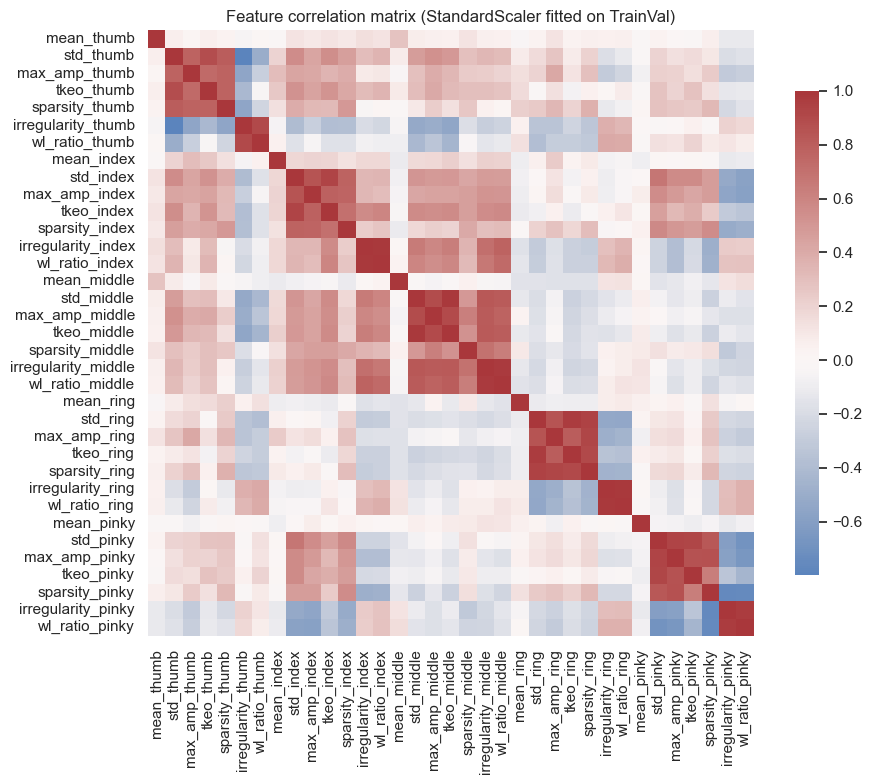

In [76]:
# --- Trial-wise feature extraction (stimulus, repetition) + stratified split ---
from sklearn.model_selection import StratifiedKFold

eps = 1e-12

def _tkeo_mean(x: np.ndarray) -> float:
    # Teager–Kaiser energy operator: ψ[x[n]] = x[n]^2 - x[n-1]x[n+1]
    if x.size < 3:
        return 0.0
    return float(np.mean(x[1:-1] ** 2 - x[:-2] * x[2:]))

def _hoyer_sparsity(x: np.ndarray, eps: float = 1e-12) -> float:
    # Hoyer sparsity in [0, 1] for non-negative vectors; we use abs(.) for EMG.
    v = np.abs(x).astype(float)
    n = v.size
    if n == 0:
        return 0.0
    l1 = np.sum(v)
    l2 = np.linalg.norm(v)
    if l2 < eps:
        return 0.0
    return float((np.sqrt(n) - (l1 / (l2 + eps))) / (np.sqrt(n) - 1.0 + eps))

def _irregularity_factor(x: np.ndarray, eps: float = 1e-12) -> float:
    # Simple time-domain irregularity: energy of first difference relative to signal energy
    if x.size < 2:
        return 0.0
    num = np.mean(np.diff(x) ** 2)
    den = np.mean(x ** 2)
    return float(np.sqrt((num + eps) / (den + eps)))

def _waveform_length_ratio(x: np.ndarray, eps: float = 1e-12) -> float:
    # Normalized waveform length: WL / sum(|x|)
    if x.size < 2:
        return 0.0
    wl = np.sum(np.abs(np.diff(x)))
    amp = np.sum(np.abs(x))
    return float(wl / (amp + eps))

FEATURE_FUNCS = {
    "mean": lambda x: float(np.mean(x)),
    "std": lambda x: float(np.std(x, ddof=0)),
    "max_amp": lambda x: float(np.max(np.abs(x))),
    "tkeo": _tkeo_mean,
    "sparsity": _hoyer_sparsity,
    "irregularity": _irregularity_factor,
    "wl_ratio": _waveform_length_ratio,
}

def extract_features_one_trial(trial_emg: np.ndarray) -> np.ndarray:
    """
    trial_emg: shape (n_samples_in_trial, n_channels)
    returns: shape (n_channels * n_features,)
    """
    feats = []
    for ch in range(trial_emg.shape[1]):
        x = trial_emg[:, ch].astype(float)
        for name in FEATURE_FUNCS:
            feats.append(FEATURE_FUNCS[name](x))
    return np.asarray(feats, dtype=float)

stimulus_1d = stimulus.squeeze().astype(int)
repetition_1d = repetition.squeeze().astype(int)

unique_stimuli = np.unique(stimulus_1d)
unique_stimuli = unique_stimuli[unique_stimuli > 0]  # ignore rest (0)
unique_reps = np.unique(repetition_1d)
unique_reps = unique_reps[unique_reps > 0]

X_list = []
Y_list = []
labels_list = []  # stimulus label per trial
meta = []         # (start, end, stim, rep, length_samples)

for stim_i in unique_stimuli:
    for rep_i in unique_reps:
        mask = (stimulus_1d == int(stim_i)) & (repetition_1d == int(rep_i))
        if not np.any(mask):
            continue

        idx = np.flatnonzero(mask)
        start = int(idx[0])
        end = int(idx[-1] + 1)
        length = int(idx.size)

        trial_emg = emg[mask, :]
        trial_glove = glove_sel[mask, :]

        X_list.append(extract_features_one_trial(trial_emg))
        Y_list.append(np.mean(trial_glove, axis=0))
        labels_list.append(int(stim_i))
        meta.append((start, end, int(stim_i), int(rep_i), length))

X = np.vstack(X_list) if X_list else np.empty((0, n_channels * len(FEATURE_FUNCS)))
Y = np.vstack(Y_list) if Y_list else np.empty((0, glove_sel.shape[1]))
labels = np.asarray(labels_list, dtype=int) if labels_list else np.empty((0,), dtype=int)
meta = np.asarray(meta, dtype=int) if meta else np.empty((0, 5), dtype=int)

print(f"Trials kept: {X.shape[0]} | Features/trial: {X.shape[1]} | Targets/trial: {Y.shape[1]}")
if meta.size:
    lengths = meta[:, 4]
    print(f"Trial length (samples): min={lengths.min()} | median={int(np.median(lengths))} | max={lengths.max()}")

# Feature names: n_features per selected channel
feature_names = []
for ch in range(n_channels):
    for feat_name in FEATURE_FUNCS:
        feature_names.append(f"{feat_name}_{channel_labels[ch]}")

df_features = pd.DataFrame(X, columns=feature_names)

# Drop any trials with non-finite values (safety)
finite_mask = np.isfinite(df_features.values).all(axis=1) & np.isfinite(Y).all(axis=1)
df_features = df_features.loc[finite_mask].reset_index(drop=True)
Y = Y[finite_mask]
labels = labels[finite_mask]
meta = meta[finite_mask]
print(f"Usable trials after finite-check: {df_features.shape[0]}")

# --- Stratified Train/Val/Test split across trials (like in philipp_1) ---
TRAIN_PCT = 0.6
VAL_PCT = 0.2
TEST_PCT = 0.2
CV_K = round((TRAIN_PCT + VAL_PCT) / VAL_PCT)  # 4 for 60/20/20
assert abs(TRAIN_PCT + VAL_PCT + TEST_PCT - 1.0) < 1e-12

X_trainval, X_test, Y_trainval, Y_test, labels_trainval, labels_test, meta_trainval, meta_test = train_test_split(
    df_features.values,
    Y,
    labels,
    meta,
    test_size=TEST_PCT,
    random_state=RANDOM_STATE,
    stratify=labels,
)

X_train, X_val, Y_train, Y_val, labels_train, labels_val, meta_train, meta_val = train_test_split(
    X_trainval,
    Y_trainval,
    labels_trainval,
    meta_trainval,
    test_size=VAL_PCT / (TRAIN_PCT + VAL_PCT),
    random_state=RANDOM_STATE,
    stratify=labels_trainval,
)

print(f"Train set size: {X_train.shape[0]} trials")
print(f"Validation set size: {X_val.shape[0]} trials")
print(f"Test set size: {X_test.shape[0]} trials")

# --- CV folds over TrainVal: stratified by stimulus label ---
skf = StratifiedKFold(n_splits=CV_K, shuffle=True, random_state=RANDOM_STATE)
folds = [val_idx for _, val_idx in skf.split(X_trainval, labels_trainval)]
print("CV fold sizes (TrainVal):", [len(f) for f in folds])

# --- Normalization for correlation visualization (fit on TRAINVAL only) ---
scaler_corr = StandardScaler()
X_trainval_scaled = scaler_corr.fit_transform(X_trainval)
df_trainval_scaled = pd.DataFrame(X_trainval_scaled, columns=feature_names)

# --- Correlation matrix (Figure) ---
corr = df_trainval_scaled.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="vlag", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation matrix (StandardScaler fitted on TrainVal)")
plt.tight_layout()
plt.show()

### 3) Correlation observations
With these time-domain features, you typically see **clusters of correlated features**:
- Features derived from overall amplitude (e.g., `std`, `max_amp`, `wl_ratio`) often correlate within a channel.
- Neighbouring fingers can also correlate because real movements recruit multiple muscles and because the EMG electrodes are not perfectly selective (cross-talk).
- Some features (e.g., `tkeo`, `irregularity`) may be less correlated with pure amplitude features and can add complementary information.

## 4–6) Regression model, metrics, and stability across fingers
We use **Gradient Boosting regression** (same family as before) in a multi-output setting to predict the five joint angles simultaneously.

**Metric choice:** we report variance-weighted $R^2$ (how much variance is explained) and also RMSE/MAE for interpretability.
$R^2$ is suitable here because it is scale-independent across dimensions and directly measures how much of the kinematic variance is captured by the model; RMSE/MAE are useful to see typical absolute errors in the glove units.

We also compute per-joint metrics to check whether performance is stable across the five angles.

Grid size: 27 candidates
[ 1/27] train R^2=+0.584 | CV val R^2=+0.482±0.028 | CV val RMSE=19.018±0.819 | params={'learning_rate': 0.01, 'max_depth': 1, 'n_estimators': 100} | best CV R^2=+0.482±0.028 (RMSE=19.018±0.819) | elapsed=1.7s | ETA=43.3s
[ 2/27] train R^2=+0.741 | CV val R^2=+0.595±0.028 | CV val RMSE=16.799±0.840 | params={'learning_rate': 0.01, 'max_depth': 1, 'n_estimators': 200} | best CV R^2=+0.595±0.028 (RMSE=16.799±0.840) | elapsed=2.8s | ETA=35.6s
[ 3/27] train R^2=+0.811 | CV val R^2=+0.635±0.024 | CV val RMSE=15.967±0.776 | params={'learning_rate': 0.01, 'max_depth': 1, 'n_estimators': 300} | best CV R^2=+0.635±0.024 (RMSE=15.967±0.776) | elapsed=3.4s | ETA=27.3s
[ 4/27] train R^2=+0.740 | CV val R^2=+0.583±0.007 | CV val RMSE=17.060±0.317 | params={'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100} | best CV R^2=+0.635±0.024 (RMSE=15.967±0.776) | elapsed=3.7s | ETA=21.3s
[ 5/27] train R^2=+0.902 | CV val R^2=+0.687±0.014 | CV val RMSE=14.770±0.283 | params=

,joint,R2,RMSE,MAE
0,angle3,0.914124,3.647211,3.019158
1,angle6,0.480026,13.847145,10.769398
2,angle8,0.770941,16.035110,12.551579
3,angle11,0.853468,12.474006,9.305929
4,angle14,0.888638,10.955243,8.622913


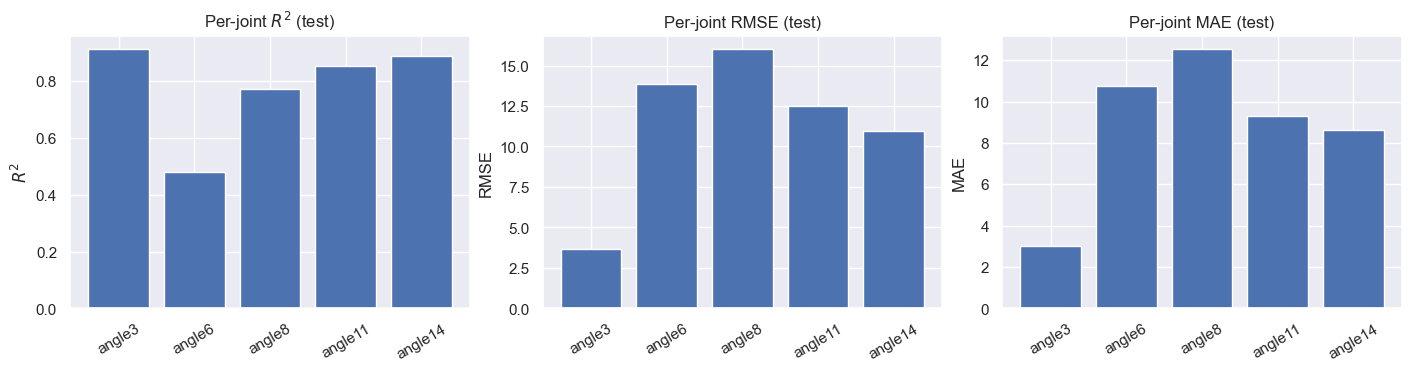

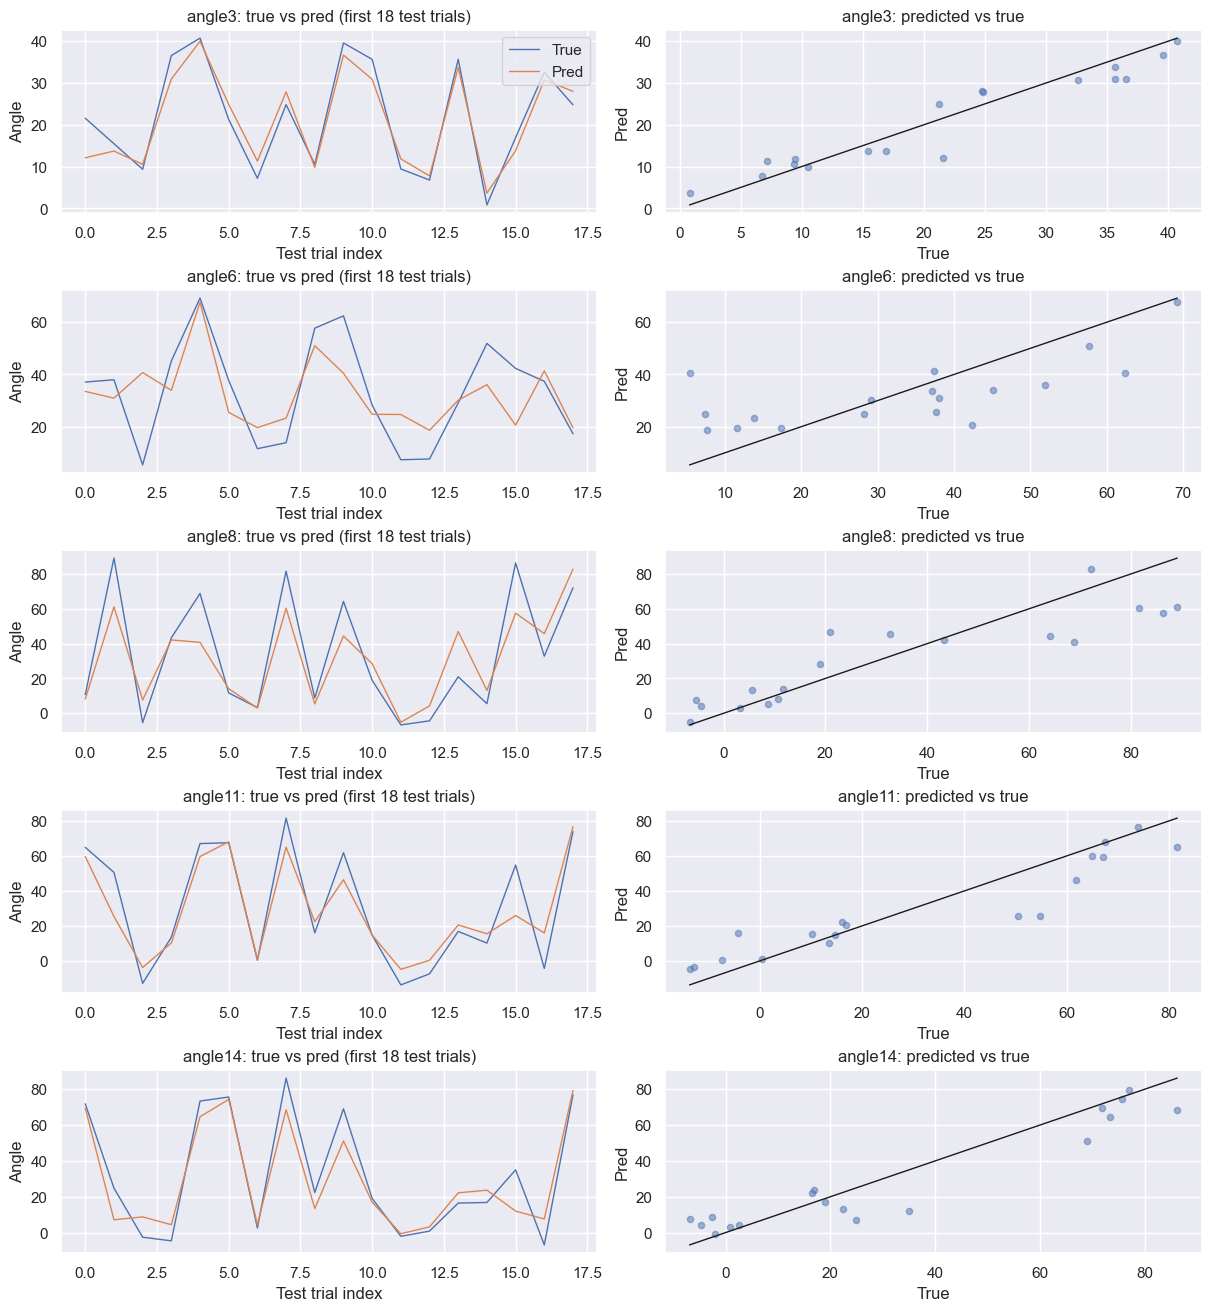

In [77]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid

# --- CV on TrainVal + final TEST ---
# Train/Val/Test was created earlier by stratifying trials by stimulus label.
# `folds` are stratified folds over TrainVal (built from labels_trainval).
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.02, 0.05],
    "max_depth": [1, 2, 3],
    # "subsample": [0.7, 0.8, 1.0],
}

def build_model(params: dict) -> Pipeline:
    gbr = GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        # subsample=float(params["subsample"]),
    )
    return Pipeline([
        ("scaler", StandardScaler()),
        ("gbr", MultiOutputRegressor(gbr, n_jobs=-1)),
    ])

grid = list(ParameterGrid(param_grid))
n_total = len(grid)
print(f"Grid size: {n_total} candidates")

all_idx = np.arange(X_trainval.shape[0])

best_params = None
best_cv_r2 = -np.inf
best_cv_r2_std = np.inf
best_cv_rmse = np.inf
best_cv_rmse_std = np.inf
t0 = time.time()

for k, params in enumerate(grid, start=1):
    fold_train_r2 = []
    fold_val_r2 = []
    fold_val_rmse = []

    for fold_i, val_idx in enumerate(folds, start=1):
        train_idx = np.setdiff1d(all_idx, val_idx)
        X_tr, Y_tr = X_trainval[train_idx], Y_trainval[train_idx]
        X_va, Y_va = X_trainval[val_idx], Y_trainval[val_idx]

        model = build_model(params)
        model.fit(X_tr, Y_tr)
        Y_tr_pred = model.predict(X_tr)
        Y_va_pred = model.predict(X_va)

        fold_train_r2.append(r2_score(Y_tr, Y_tr_pred, multioutput="variance_weighted"))
        fold_val_r2.append(r2_score(Y_va, Y_va_pred, multioutput="variance_weighted"))
        fold_val_rmse.append(float(np.sqrt(mean_squared_error(Y_va, Y_va_pred))))

    cv_r2_mean = float(np.mean(fold_val_r2))
    cv_r2_std = float(np.std(fold_val_r2))
    cv_rmse_mean = float(np.mean(fold_val_rmse))
    cv_rmse_std = float(np.std(fold_val_rmse))
    tr_r2_mean = float(np.mean(fold_train_r2))

    if cv_r2_mean > best_cv_r2:
        best_cv_r2 = cv_r2_mean
        best_cv_r2_std = cv_r2_std
        best_cv_rmse = cv_rmse_mean
        best_cv_rmse_std = cv_rmse_std
        best_params = params

    elapsed = time.time() - t0
    avg = elapsed / k
    eta = avg * (n_total - k)
    print(
        f"[{k:>2}/{n_total}] train R^2={tr_r2_mean:+.3f} | CV val R^2={cv_r2_mean:+.3f}±{cv_r2_std:.3f} | CV val RMSE={cv_rmse_mean:.3f}±{cv_rmse_std:.3f} "
        f"| params={params} | best CV R^2={best_cv_r2:+.3f}±{best_cv_r2_std:.3f} (RMSE={best_cv_rmse:.3f}±{best_cv_rmse_std:.3f}) "
        f"| elapsed={elapsed:.1f}s | ETA={eta:.1f}s",
        flush=True,
    )

print("\nBest params (selected by mean CV val R^2):", best_params)
print(f"Best CV val R^2 (mean±std): {best_cv_r2:+.3f}±{best_cv_r2_std:.3f}")
print(f"Best CV val RMSE (mean±std): {best_cv_rmse:.3f}±{best_cv_rmse_std:.3f}")

# --- Fit best model on full TrainVal, then evaluate on Test ---
final_model = build_model(best_params)
t_fit = time.time()
final_model.fit(X_trainval, Y_trainval)

Y_trainval_pred = final_model.predict(X_trainval)
r2_trainval = r2_score(Y_trainval, Y_trainval_pred, multioutput="variance_weighted")
print(f"\nTRAINVAL R^2 (variance-weighted, final model): {r2_trainval:+.3f}")

Y_pred = final_model.predict(X_test)
print(f"Final fit+predict time: {time.time() - t_fit:.2f} s")

# --- Metrics on TEST ---
r2_overall = r2_score(Y_test, Y_pred, multioutput="variance_weighted")
rmse_overall = float(np.sqrt(mean_squared_error(Y_test, Y_pred)))
mae_overall = float(mean_absolute_error(Y_test, Y_pred))
print(f"TEST R^2 (variance-weighted): {r2_overall:+.3f}")
print(f"TEST RMSE (overall): {rmse_overall:.3f}")
print(f"TEST MAE  (overall): {mae_overall:.3f}")

# Per-joint metrics
r2_per_joint = r2_score(Y_test, Y_pred, multioutput="raw_values")
rmse_per_joint = np.sqrt(np.mean((Y_test - Y_pred) ** 2, axis=0))
mae_per_joint = np.mean(np.abs(Y_test - Y_pred), axis=0)

metrics_df = pd.DataFrame({
    "joint": joint_names,
    "R2": r2_per_joint,
    "RMSE": rmse_per_joint,
    "MAE": mae_per_joint,
})
display(metrics_df)

# --- Visualize stability across joints ---
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
axes[0].bar(joint_names, r2_per_joint)
axes[0].axhline(0, color="k", linewidth=1)
axes[0].set_title("Per-joint $R^2$ (test)")
axes[0].set_ylabel("$R^2$")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(joint_names, rmse_per_joint)
axes[1].set_title("Per-joint RMSE (test)")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(joint_names, mae_per_joint)
axes[2].set_title("Per-joint MAE (test)")
axes[2].set_ylabel("MAE")
axes[2].tick_params(axis="x", rotation=30)
plt.show()

# --- Visualize predictions vs ground truth (time series + scatter) ---
n_show = min(200, Y_test.shape[0])
fig, axes = plt.subplots(len(joint_names), 2, figsize=(12, 2.6 * len(joint_names)), constrained_layout=True)
if len(joint_names) == 1:
    axes = np.array([axes])
for i, name in enumerate(joint_names):
    axes[i, 0].plot(Y_test[:n_show, i], label="True", linewidth=1)
    axes[i, 0].plot(Y_pred[:n_show, i], label="Pred", linewidth=1)
    axes[i, 0].set_title(f"{name}: true vs pred (first {n_show} test trials)")
    axes[i, 0].set_xlabel("Test trial index")
    axes[i, 0].set_ylabel("Angle")
    if i == 0:
        axes[i, 0].legend(loc="upper right")

    axes[i, 1].scatter(Y_test[:, i], Y_pred[:, i], s=20, alpha=0.5)
    vmin = float(min(Y_test[:, i].min(), Y_pred[:, i].min()))
    vmax = float(max(Y_test[:, i].max(), Y_pred[:, i].max()))
    axes[i, 1].plot([vmin, vmax], [vmin, vmax], color="k", linewidth=1)
    axes[i, 1].set_title(f"{name}: predicted vs true")
    axes[i, 1].set_xlabel("True")
    axes[i, 1].set_ylabel("Pred")
plt.show()

## Diagnostics: baselines, residuals, and split sanity checks
These cells directly test the claim “validation $R^2 < 0$ means worse than predicting the mean”, and help localize the failure mode:
- **Baselines:** mean/median predictors + linear (Ridge/OLS) on the *same folds* you used for CV.
- **Residual/variance checks:** do predictions collapse to the mean? Are a few points dominating error?
- **Split shift:** are the *targets* or *stimulus distribution* different in the held-out tail (test) vs earlier segments (trainval)?

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def _metrics_multioutput(y_true: np.ndarray, y_pred: np.ndarray, joint_names: list[str] | None = None) -> tuple[dict, pd.DataFrame]:
    """Return overall metrics + per-joint table."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    assert y_true.shape == y_pred.shape, f"Shape mismatch: {y_true.shape} vs {y_pred.shape}"

    overall = {
        "R2_var_weighted": float(r2_score(y_true, y_pred, multioutput="variance_weighted")),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
    }

    r2_per = r2_score(y_true, y_pred, multioutput="raw_values")
    rmse_per = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    mae_per = np.mean(np.abs(y_true - y_pred), axis=0)
    var_true = np.var(y_true, axis=0, ddof=0)
    var_pred = np.var(y_pred, axis=0, ddof=0)
    var_ratio = var_pred / (var_true + 1e-12)

    if joint_names is None:
        joint_names = [f"y{i}" for i in range(y_true.shape[1])]

    per_joint = pd.DataFrame({
        "joint": joint_names,
        "R2": r2_per,
        "RMSE": rmse_per,
        "MAE": mae_per,
        "VarRatio_pred/true": var_ratio,
    })
    return overall, per_joint

def _evaluate_on_folds(model, X: np.ndarray, Y: np.ndarray, folds: list[np.ndarray], joint_names: list[str]) -> pd.DataFrame:
    """Blocked-fold evaluation (same fold structure you already used)."""
    all_idx = np.arange(X.shape[0])
    rows = []
    for fold_i, val_idx in enumerate(folds, start=1):
        train_idx = np.setdiff1d(all_idx, val_idx)
        X_tr, Y_tr = X[train_idx], Y[train_idx]
        X_va, Y_va = X[val_idx], Y[val_idx]

        model.fit(X_tr, Y_tr)
        Y_va_pred = model.predict(X_va)
        overall, _ = _metrics_multioutput(Y_va, Y_va_pred, joint_names)
        rows.append({"fold": fold_i, **overall})
    df = pd.DataFrame(rows)
    df.loc["mean"] = df.drop(columns=["fold"]).mean(numeric_only=True)
    df.loc["std"] = df.drop(columns=["fold"]).std(numeric_only=True)
    return df

# --- Baselines on your TrainVal folds ---
assert "X_trainval" in globals() and "Y_trainval" in globals() and "folds" in globals(), "Run the feature extraction + fold creation cell first."
assert "joint_names" in globals(), "Expected joint_names to exist."

baseline_mean = DummyRegressor(strategy="mean")
baseline_median = DummyRegressor(strategy="median")

ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0, random_state=RANDOM_STATE))])
ols = Pipeline([("scaler", StandardScaler()), ("ols", LinearRegression())])

results = []
for name, model in [
    ("DummyMean", baseline_mean),
    ("DummyMedian", baseline_median),
    ("Ridge(alpha=1)", ridge),
    ("OLS", ols),
]:
    df = _evaluate_on_folds(model, X_trainval, Y_trainval, folds, joint_names)
    df.insert(0, "model", name)
    results.append(df.reset_index().rename(columns={"index": "row"}))

baselines_cv = pd.concat(results, ignore_index=True)
display(baselines_cv)

# Quick view: mean row only
summary = baselines_cv[baselines_cv["row"] == "mean"].drop(columns=["row"]).reset_index(drop=True)
display(summary.sort_values(by="R2_var_weighted", ascending=False))

,row,model,fold,R2_var_weighted,RMSE,MAE
0,0,DummyMean,1.0,-0.003852,25.683230,21.879313
1,1,DummyMean,2.0,-0.000903,26.494052,22.529684
2,2,DummyMean,3.0,-0.001199,27.337196,22.734230
3,3,DummyMean,4.0,-0.001517,26.267389,21.778225
4,mean,DummyMean,NaN,-0.001868,26.445467,22.230363
5,std,DummyMean,NaN,0.001166,0.593771,0.409616
6,0,DummyMedian,1.0,-0.038005,26.116475,20.674183
7,1,DummyMedian,2.0,-0.068793,27.377836,22.035723
8,2,DummyMedian,3.0,-0.064347,28.186124,21.859106
9,3,DummyMedian,4.0,-0.095266,27.469304,21.687160


,model,fold,R2_var_weighted,RMSE,MAE
2,Ridge(alpha=1),NaN,0.672934,15.094359,11.443785
3,OLS,NaN,0.329195,21.503965,15.381367
0,DummyMean,NaN,-0.001868,26.445467,22.230363
1,DummyMedian,NaN,-0.066603,27.287435,21.564043


## Diagnostics: residual structure + split shift (TrainVal vs Test)
If your boosted model is truly worse than a mean baseline on held-out data, you’ll typically see at least one of:
- **Prediction collapse:** predicted variance 80–90% smaller than target variance (VarRatio $\ll 1$).
- **Outlier domination:** a handful of trials contribute disproportionate squared error.
- **Distribution shift:** target means/variances or stimulus composition differ between TrainVal and Test.

Final model TEST metrics: {'R2_var_weighted': 0.8051166624864223, 'RMSE': 12.147333133586939, 'MAE': 8.853795448101062}


,joint,R2,RMSE,MAE,VarRatio_pred/true
0,angle3,0.914124,3.647211,3.019158,0.804463
1,angle6,0.480026,13.847145,10.769398,0.412008
2,angle8,0.770941,16.035110,12.551579,0.552650
3,angle11,0.853468,12.474006,9.305929,0.635799
4,angle14,0.888638,10.955243,8.622913,0.742711


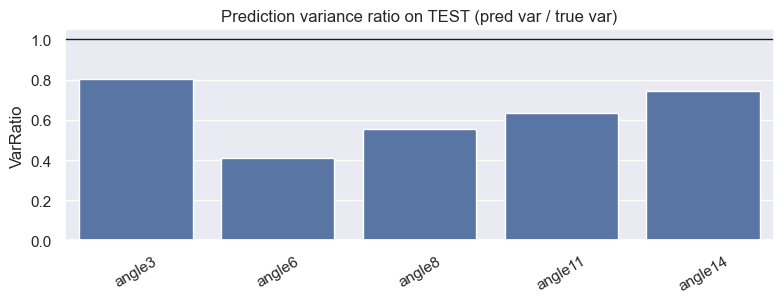

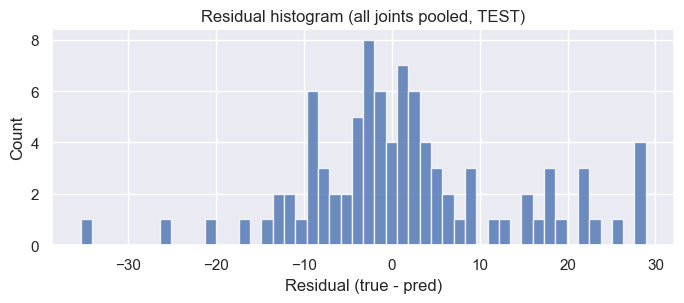

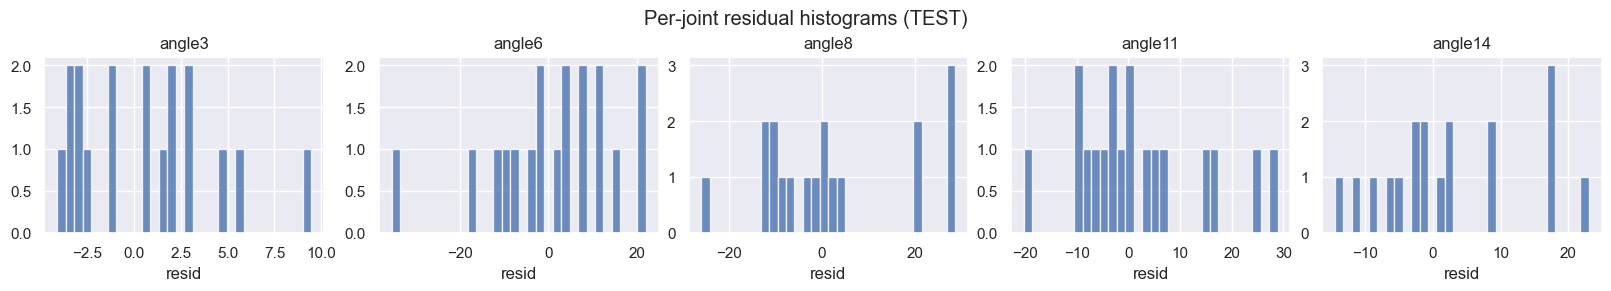

Top-10 trials account for 89.7% of total squared error on TEST


,joint,mean_trainval,mean_test,std_trainval,std_test,mean_diff(test-trainval),std_ratio(test/trainval)
0,angle3,20.468536,21.641878,12.879668,12.445888,1.173342,0.966321
1,angle6,33.033539,33.289402,19.544830,19.203020,0.255863,0.982511
2,angle8,32.056995,33.411682,32.156929,33.504128,1.354687,1.041895
3,angle11,29.040201,30.867086,29.838589,32.586678,1.826885,1.092098
4,angle14,29.430368,31.919699,31.992016,32.828671,2.489330,1.026152


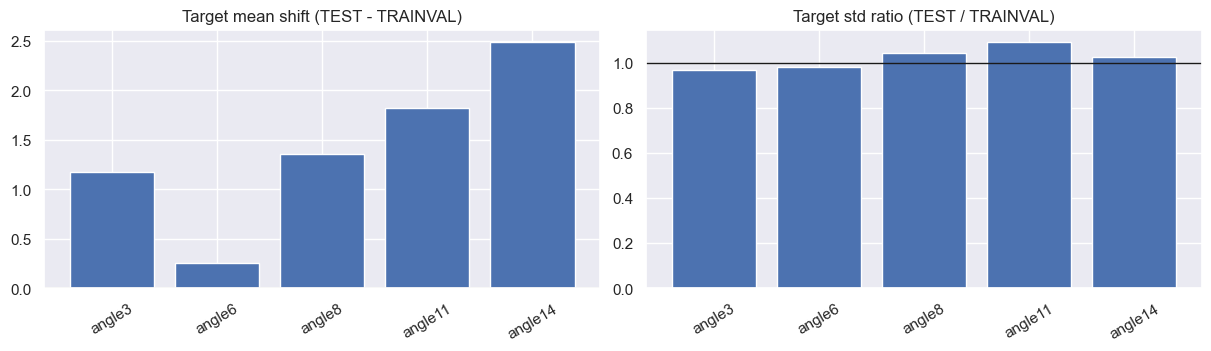

,TrainVal,Test,TrainVal_frac,Test_frac
1,8,2,0.111111,0.111111
2,8,2,0.111111,0.111111
3,8,2,0.111111,0.111111
4,8,2,0.111111,0.111111
5,8,2,0.111111,0.111111
6,8,2,0.111111,0.111111
7,8,2,0.111111,0.111111
8,8,2,0.111111,0.111111
9,8,2,0.111111,0.111111


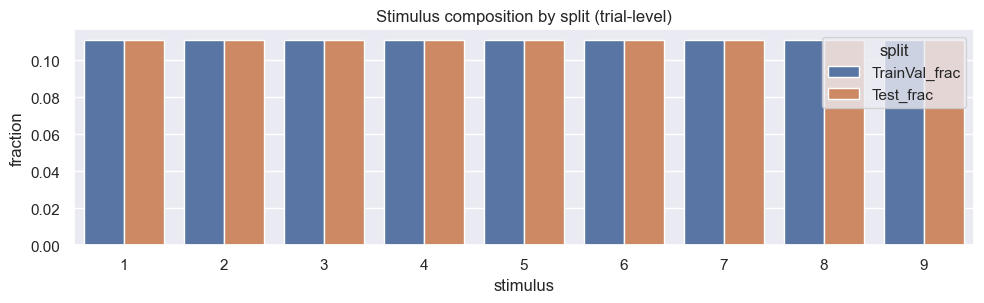

In [79]:
# --- Residual diagnostics on TEST for your final_model ---
assert "final_model" in globals(), "Run the GradientBoosting regression cell first so final_model exists."
assert "X_test" in globals() and "Y_test" in globals(), "Expected X_test/Y_test to exist."

Y_test_pred = final_model.predict(X_test)
overall_test, per_joint_test = _metrics_multioutput(Y_test, Y_test_pred, joint_names)
print("Final model TEST metrics:", overall_test)
display(per_joint_test)

# 1) Are predictions collapsing toward the mean? (VarRatio)
plt.figure(figsize=(8, 3.2))
sns.barplot(data=per_joint_test, x="joint", y="VarRatio_pred/true", color=sns.color_palette()[0])
plt.axhline(1.0, color="k", linewidth=1)
plt.title("Prediction variance ratio on TEST (pred var / true var)")
plt.ylabel("VarRatio")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 2) Residual distribution (overall) + per-joint residual histograms
resid = Y_test - Y_test_pred  # shape (n_test, n_joints)
plt.figure(figsize=(7, 3.2))
plt.hist(resid.ravel(), bins=50, alpha=0.8)
plt.title("Residual histogram (all joints pooled, TEST)")
plt.xlabel("Residual (true - pred)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(joint_names), figsize=(3.2 * len(joint_names), 2.8), constrained_layout=True)
axes = np.atleast_1d(axes)
for i, name in enumerate(joint_names):
    axes[i].hist(resid[:, i], bins=30, alpha=0.8)
    axes[i].set_title(name)
    axes[i].set_xlabel("resid")
plt.suptitle("Per-joint residual histograms (TEST)")
plt.show()

# 3) Outlier domination: top-k squared errors
se_per_trial = np.sum(resid ** 2, axis=1)
order = np.argsort(se_per_trial)[::-1]
topk = min(10, se_per_trial.size)
top_share = float(np.sum(se_per_trial[order[:topk]]) / (np.sum(se_per_trial) + 1e-12))
print(f"Top-{topk} trials account for {top_share*100:.1f}% of total squared error on TEST")

# --- Split shift checks (TrainVal vs Test) ---
# Targets distribution shift
Y_trainval_mean = np.mean(Y_trainval, axis=0)
Y_test_mean = np.mean(Y_test, axis=0)
Y_trainval_std = np.std(Y_trainval, axis=0, ddof=0)
Y_test_std = np.std(Y_test, axis=0, ddof=0)

shift_df = pd.DataFrame({
    "joint": joint_names,
    "mean_trainval": Y_trainval_mean,
    "mean_test": Y_test_mean,
    "std_trainval": Y_trainval_std,
    "std_test": Y_test_std,
    "mean_diff(test-trainval)": (Y_test_mean - Y_trainval_mean),
    "std_ratio(test/trainval)": (Y_test_std / (Y_trainval_std + 1e-12)),
})
display(shift_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), constrained_layout=True)
axes[0].bar(joint_names, shift_df["mean_diff(test-trainval)"].values)
axes[0].axhline(0, color="k", linewidth=1)
axes[0].set_title("Target mean shift (TEST - TRAINVAL)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(joint_names, shift_df["std_ratio(test/trainval)"].values)
axes[1].axhline(1, color="k", linewidth=1)
axes[1].set_title("Target std ratio (TEST / TRAINVAL)")
axes[1].tick_params(axis="x", rotation=30)
plt.show()

# Stimulus distribution shift across trials
if "labels_trainval" in globals() and "labels_test" in globals():
    dist_trainval = pd.Series(labels_trainval).value_counts().sort_index()
    dist_test = pd.Series(labels_test).value_counts().sort_index()
    dist = pd.DataFrame({"TrainVal": dist_trainval, "Test": dist_test}).fillna(0).astype(int)
    dist["TrainVal_frac"] = dist["TrainVal"] / max(1, dist["TrainVal"].sum())
    dist["Test_frac"] = dist["Test"] / max(1, dist["Test"].sum())
    display(dist)

    dist_plot = dist.reset_index(names="stim")
    dist_long = dist_plot.melt(id_vars="stim", value_vars=["TrainVal_frac", "Test_frac"], var_name="split", value_name="frac")
    plt.figure(figsize=(10, 3.2))
    sns.barplot(data=dist_long, x="stim", y="frac", hue="split")
    plt.title("Stimulus composition by split (trial-level)")
    plt.xlabel("stimulus")
    plt.ylabel("fraction")
    plt.tight_layout()
    plt.show()
else:
    print("labels_trainval/labels_test not found; skipping stimulus distribution shift check.")